### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [8]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

Some Urban Images: 


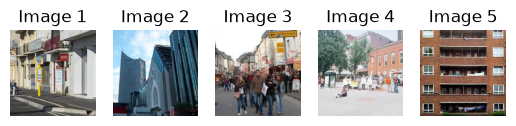

Some Rural Images: 


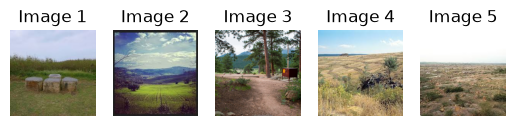

In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder_path_urban = "./images/val/urban"
folder_path_rural = "./images/val/rural"

jpeg_files_urban = [f for f in os.listdir(folder_path_urban) if f.endswith(".jpeg") or f.endswith(".jpg")]
jpeg_files_rural = [f for f in os.listdir(folder_path_rural) if f.endswith(".jpeg") or f.endswith(".jpg")]

num_photos_to_display = 5
print("Some Urban Images: ")
for i, jpeg_file in enumerate(jpeg_files_urban[:num_photos_to_display]):
    image_path = os.path.join(folder_path_urban, jpeg_file)
    image = Image.open(image_path)
    plt.subplot(1, num_photos_to_display, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image {i + 1}")
plt.show()
print("Some Rural Images: ")
for i, jpeg_file in enumerate(jpeg_files_rural[:num_photos_to_display]):
    image_path = os.path.join(folder_path_rural, jpeg_file)
    image = Image.open(image_path)
    plt.subplot(1, num_photos_to_display, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image {i + 1}")
plt.show()


In [10]:
for i, jpeg_file in enumerate(jpeg_files_rural[:num_photos_to_display]):
    image_path = os.path.join(folder_path_rural, jpeg_file)
    image = Image.open(image_path)
    width, height = image.size
    print(f"Image Size (Width x Height): {width} x {height} pixels")

Image Size (Width x Height): 225 x 225 pixels
Image Size (Width x Height): 225 x 225 pixels
Image Size (Width x Height): 800 x 800 pixels
Image Size (Width x Height): 225 x 225 pixels
Image Size (Width x Height): 225 x 225 pixels


In [11]:
print("val urban count: ", len(jpeg_files_urban))
print("val rural count: ", len(jpeg_files_rural))
folder_path_urban = "./images/train/urban"
folder_path_rural = "./images/train/rural"

jpeg_files_urban = [f for f in os.listdir(folder_path_urban) if f.endswith(".jpeg") or f.endswith(".jpg")]
jpeg_files_rural = [f for f in os.listdir(folder_path_rural) if f.endswith(".jpeg") or f.endswith(".jpg")]

print("train urban count: ", len(jpeg_files_urban))
print("train rural count: ", len(jpeg_files_rural))



val urban count:  10
val rural count:  10
train urban count:  36
train rural count:  36


In [12]:
import keras

target_size = (224, 224)
batch_size_train = 12
batch_size_val = 4

# Load training dataset
train_generator = keras.utils.image_dataset_from_directory(
    './images/train',
    image_size=target_size,
    batch_size=batch_size_train,
    shuffle=False,
    label_mode='categorical'  # Replaces class_mode='categorical'
)

# Load validation dataset
validation_generator = keras.utils.image_dataset_from_directory(
    './images/val',
    image_size=target_size,
    batch_size=batch_size_val,
    shuffle=False,
    label_mode='categorical'
)

# Rescale pixel values from [0, 255] to [0, 1] using a pipeline map
rescale_layer = keras.layers.Rescaling(1.0 / 255)

train_generator = train_generator.map(lambda x, y: (rescale_layer(x), y))
validation_generator = validation_generator.map(lambda x, y: (rescale_layer(x), y))

Found 72 files belonging to 2 classes.
Found 20 files belonging to 2 classes.


In [13]:
import random
import numpy as np
import tensorflow as tf
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)


In [14]:
from keras.models import Sequential
from keras.layers import Input,Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'  ))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='relu' ))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))


In [15]:
model.compile(optimizer='adam',  # Adjust learning rate if needed
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [16]:
epochs = 40
history = model.fit(
    x=train_generator,
    epochs=epochs,
    steps_per_epoch=len(train_generator),
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/40


/home/aziz1/miniconda3/envs/tf_gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 441ms/step - accuracy: 0.3889 - loss: 16.0788 - val_accuracy: 0.5000 - val_loss: 0.7135
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 0.8573 - val_accuracy: 0.5000 - val_loss: 0.6867
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.7190 - val_accuracy: 0.5000 - val_loss: 0.6900
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4861 - loss: 0.6964 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5139 - loss: 0.6897 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.6878
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.6856 - val_accuracy: 0.5500 - val_loss: 0.6844
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5139 - loss: 0.6845 - val_accuracy: 0.6500 - val_loss: 0.6811
Epoch 9/

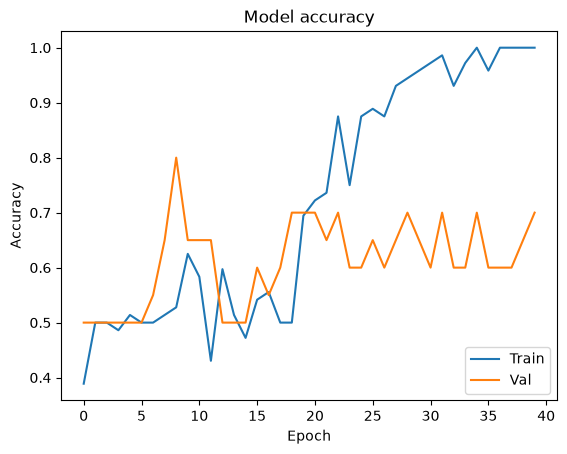

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()


In [19]:
# Evaluate directly without calling .reset() or manually specifying steps
score = model.evaluate(train_generator)

print('Train accuracy:', round(score[1] * 100, 2))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 0.0061
Train accuracy: 100.0


In [21]:
score = model.evaluate(validation_generator)
print('Test accuracy:', round(score[1] * 100, 2))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7000 - loss: 1.9256
Test accuracy: 70.0


Found 20 files belonging to 2 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


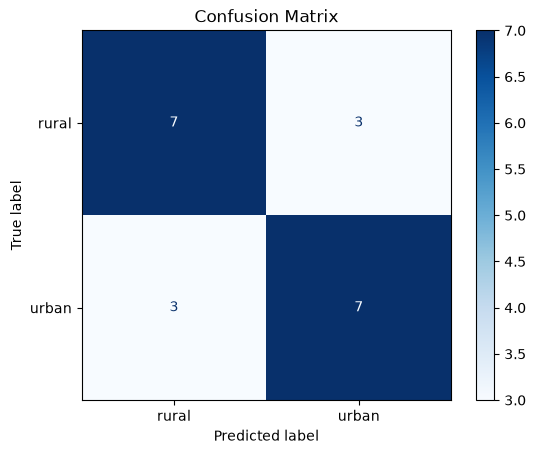

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Re-evaluate or recreate dataset to store class names cleanly
# (Note: image_dataset_from_directory provides class_names on creation)
val_ds_raw = keras.utils.image_dataset_from_directory(
    './images/val',
    image_size=(224, 224),
    batch_size=4,
    shuffle=False,
    label_mode='categorical'
)

# Extract class names
class_labels = val_ds_raw.class_names

# Map normalization layer
rescale_layer = keras.layers.Rescaling(1.0 / 255)
validation_generator = val_ds_raw.map(lambda x, y: (rescale_layer(x), y))

# 2. Predict on dataset (no reset needed)
y_pred = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(y_pred, axis=1)

# 3. Extract ground truth labels (y_true) from the mapped dataset
y_true = np.concatenate([y.numpy() for _, y in validation_generator], axis=0)
y_true = np.argmax(y_true, axis=1)  # Convert one-hot vectors to class indices

# 4. Generate and display confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


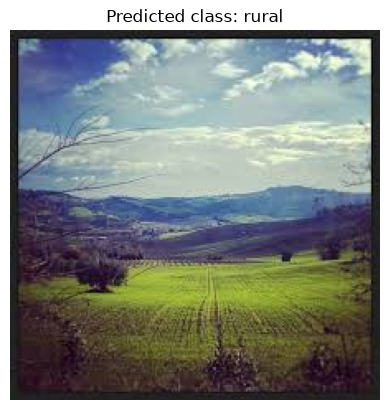

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import keras

# 1. Fixed Linux file path (forward slashes)
img_path = 'images/val/rural/rural10.jpeg'

# 2. Modern Keras image loading
img = keras.utils.load_img(img_path, target_size=(224, 224))
img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Model prediction
prediction = model.predict(img_array)
class_index = np.argmax(prediction, axis=1)[0]

# 4. Extract label using class_names from your raw Dataset object
predicted_class_label = val_ds_raw.class_names[class_index]

# 5. Display image with prediction
plt.imshow(img)
plt.title(f'Predicted class: {predicted_class_label}')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


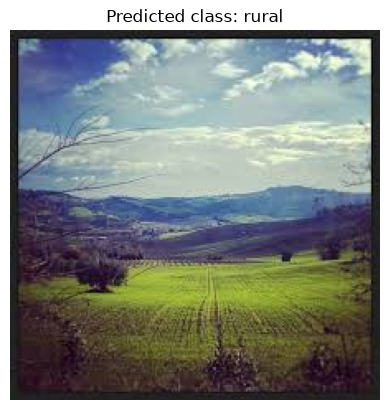

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras

# 1. Correct Linux path (forward slashes)
img_path = 'images/val/rural/rural10.jpeg'

# 2. Modern Keras image loading
img = keras.utils.load_img(img_path, target_size=(224, 224))
img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Predict class
prediction = model.predict(img_array)
class_index = np.argmax(prediction, axis=1)[0]

# 4. Extract class names (uses sorted directory names to match Keras index order)
train_dir = './images/train'
class_labels = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
predicted_class_label = class_labels[class_index]

# 5. Display result
plt.imshow(img)
plt.title(f'Predicted class: {predicted_class_label}')
plt.axis('off')
plt.show()

Processing Urban Images...
Processing Rural Images...


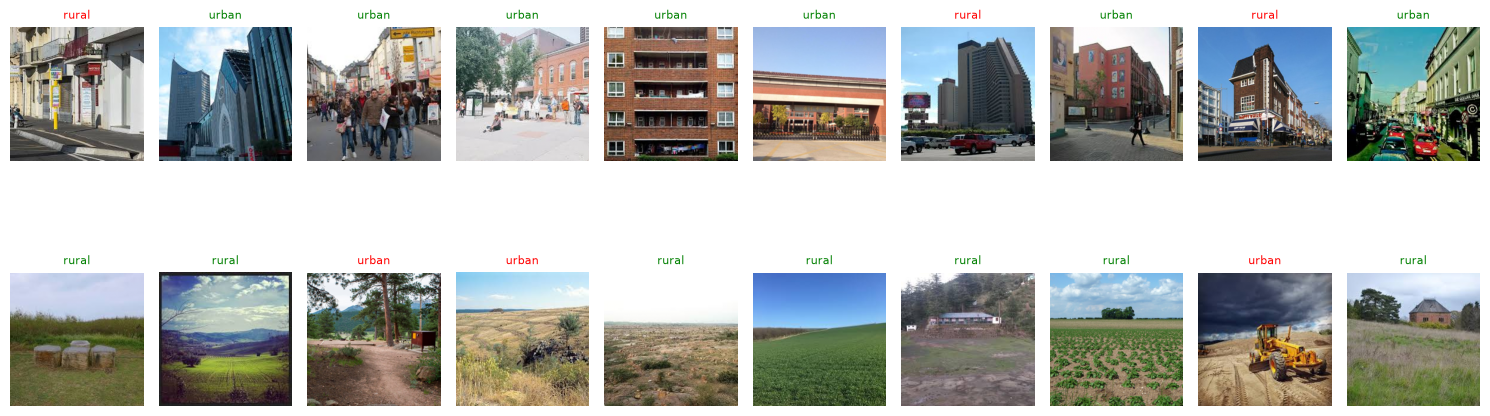

In [31]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def load_and_preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')  # Ensure 3 channels
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    return img_array

# 1. Use cross-platform, Linux-compatible paths
folder_path_urban = os.path.join("images", "val", "urban")
folder_path_rural = os.path.join("images", "val", "rural")

jpeg_files_urban = [f for f in os.listdir(folder_path_urban) if f.lower().endswith(('.jpeg', '.jpg'))]
jpeg_files_rural = [f for f in os.listdir(folder_path_rural) if f.lower().endswith(('.jpeg', '.jpg'))]

# 2. Extract class labels safely (sorted directory order matches Keras index conventions)
train_dir = os.path.join("images", "train")
class_labels = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

num_photos_to_display = 10
plt.figure(figsize=(15, 6))

# Process Urban Images (Row 1)
true_class = "urban"
print("Processing Urban Images...")
for i, jpeg_file in enumerate(jpeg_files_urban[:num_photos_to_display]):
    image_path = os.path.join(folder_path_urban, jpeg_file)
    img_array = load_and_preprocess_image(image_path)

    prediction = model.predict(np.expand_dims(img_array, axis=0), verbose=0)
    class_index = np.argmax(prediction, axis=1)[0]
    predicted_class = class_labels[class_index]

    text_color = 'green' if true_class == predicted_class else 'red'
    
    # Row 1 positions: 1 to 10
    plt.subplot(2, num_photos_to_display, i + 1)
    plt.imshow(img_array)
    plt.title(predicted_class, fontsize=8, color=text_color)
    plt.axis("off")

# Process Rural Images (Row 2)
true_class = "rural"
print("Processing Rural Images...")
for i, jpeg_file in enumerate(jpeg_files_rural[:num_photos_to_display]):
    image_path = os.path.join(folder_path_rural, jpeg_file)
    img_array = load_and_preprocess_image(image_path)

    prediction = model.predict(np.expand_dims(img_array, axis=0), verbose=0)
    class_index = np.argmax(prediction, axis=1)[0]
    predicted_class = class_labels[class_index]

    text_color = 'green' if true_class == predicted_class else 'red'
    
    # Row 2 positions: 11 to 20
    plt.subplot(2, num_photos_to_display, i + 1 + num_photos_to_display)
    plt.imshow(img_array)
    plt.title(predicted_class, fontsize=8, color=text_color)
    plt.axis("off")

plt.tight_layout()
plt.show()